#### Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping

#### Data Reading

In [178]:
df = pd.read_csv("housing.csv",encoding_errors='ignore')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


##### No. of Rows and Columns

In [179]:
df.shape

(20640, 10)

#### Data Preprocssing and Scaling

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [181]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

##### Checking for null values

In [182]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

##### Droping the missing values

In [183]:
df.dropna(inplace=True)

##### Mapping values

In [184]:
df['ocean_proximity'] = df['ocean_proximity'].map({"<1H OCEAN":0,"INLAND":1,"NEAR OCEAN":2,"NEAR BAY":3,"ISLAND":4})

#### Train Test Split

In [185]:
X = df.drop("median_house_value",axis=1)
y = df["median_house_value"]

In [186]:
X = np.array(X)
y = np.array(y)

In [187]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=27)
X_train.shape

(16346, 9)

#### Scaling Values

In [188]:
scaler = MinMaxScaler()
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[0.53884462, 0.17428268, 0.45098039, ..., 0.09537905, 0.37396036,
        0.        ],
       [0.64043825, 0.12858661, 0.1372549 , ..., 0.0927479 , 0.19744555,
        0.        ],
       [0.62051793, 0.1392136 , 0.70588235, ..., 0.06544976, 0.2890236 ,
        0.        ],
       ...,
       [0.5249004 , 0.38150903, 0.39215686, ..., 0.0610097 , 0.1829561 ,
        0.25      ],
       [0.16832669, 0.66631243, 0.41176471, ..., 0.02318698, 0.20259031,
        0.25      ],
       [0.19123506, 0.55366631, 1.        , ..., 0.07794771, 0.24530006,
        0.75      ]], shape=(4087, 9))

#### Building Model (ANN)

In [189]:
model = Sequential()

model.add(Dense(500, activation='relu', input_dim=9))
model.add(BatchNormalization()) 
model.add(Dropout(0.2))

model.add(Dense(500, activation='relu'))
model.add(BatchNormalization()) 
model.add(Dropout(0.2))

model.add(Dense(500, activation='relu'))
model.add(BatchNormalization()) 
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))

c:\Users\gball\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [190]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 500)            │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,501 (1.96 MB)

 Trainable params: 509,501 (1.94 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [191]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

es = EarlyStopping(
    monitor='val_loss',    
    mode='min',          
    patience=10,         
    min_delta=1e-4,         
    restore_best_weights=True,
    verbose=1
)

In [192]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),callbacks=[es],epochs=120,batch_size=50,verbose=1)

Epoch 1/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 56188301312.0000 - mae: 206925.3281 - val_loss: 55780720640.0000 - val_mae: 206721.7500
Epoch 2/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 56030978048.0000 - mae: 206698.1094 - val_loss: 55662501888.0000 - val_mae: 206563.8906
Epoch 3/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 55721553920.0000 - mae: 206223.2656 - val_loss: 55277604864.0000 - val_mae: 206019.0312
Epoch 4/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 55258943488.0000 - mae: 205513.0312 - val_loss: 54651105280.0000 - val_mae: 204867.6094
Epoch 5/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 54683713536.0000 - mae: 204591.5312 - val_loss: 55406522368.0000 - val_mae: 206926.3281
Epoch 6/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 54008541184.0000 - mae: 203489.6094 - val_loss: 53336207360.0000 - val_mae: 202491.1562
Epoch 7/120
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 53244313600.0000 - mae: 202214.3125 - val_los

#### Metrices and Scores

In [193]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred = model.predict(X_test)
print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
mae : 42178.48132225654
mse : 3569129357.7631245
score : 0.7268964840078638


#### Analysis via Graph

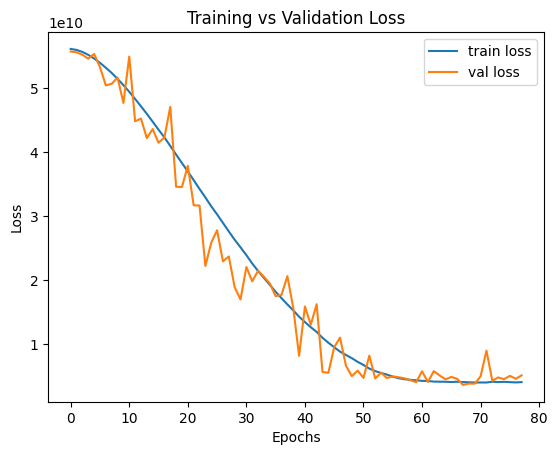

In [194]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()